In [1]:
import pandas as pd
import numpy as np
import os
import json
import joblib
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print(" Libraries imported successfully!")

c:\Users\prasa\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


 Libraries imported successfully!


In [2]:


DATA_PATH = '../backend/data/AQ of adoloscents - Sheet.csv' 

df = pd.read_csv(DATA_PATH)


if 'Q1' not in df.columns:
    question_cols = df.columns[0:9] 
    rename_map = {col: f'Q{i+1}' for i, col in enumerate(question_cols)}
    df = df.rename(columns=rename_map)

# Engineer Target_Category
if 'Target_Category' not in df.columns:
    def categorize_aq(score):
        if score < 2.5: return 0      # Low
        elif score < 3.5: return 1    # Medium
        else: return 2                # High
    df['Target_Category'] = df['AQ'].apply(categorize_aq)

features = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10']
X = df[features]
y = df['Target_Category']

print(f"Data Loaded. Shape: {df.shape}")
df[features + ['Target_Category']].head()

Data Loaded. Shape: (114, 16)


,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Target_Category
0,4,5,4,4,5,4,3,4,5,4,2
1,4,4,3,4,4,4,4,4,4,5,2
2,5,5,5,5,3,3,3,2,5,3,2
3,5,5,4,5,5,5,5,5,5,4,2
4,4,4,3,5,4,4,5,4,4,3,2


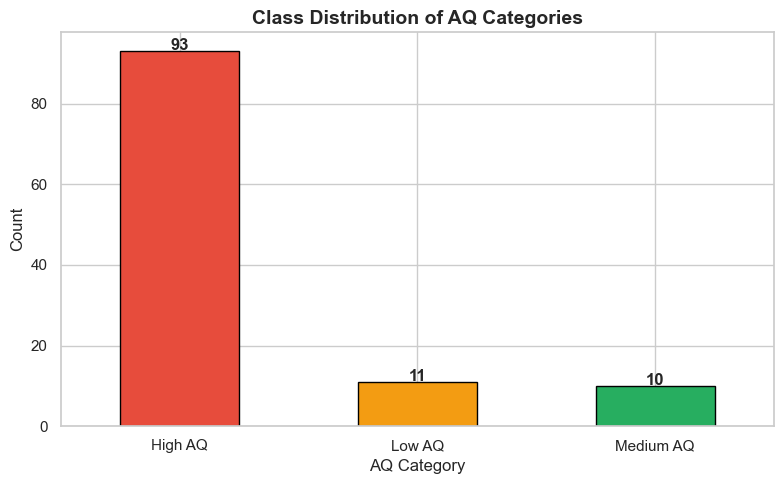


Class Distribution:
Target_Category
High AQ      93
Low AQ       11
Medium AQ    10
Name: count, dtype: int64


In [3]:
# Class distribution
class_labels = {0: 'Low AQ', 1: 'Medium AQ', 2: 'High AQ'}
class_counts = y.map(class_labels).value_counts()

plt.figure(figsize=(8, 5))
ax = class_counts.plot(kind='bar', color=['#e74c3c', '#f39c12', '#27ae60'], edgecolor='black')
plt.title('Class Distribution of AQ Categories', fontsize=14, fontweight='bold')
plt.xlabel('AQ Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
for i, v in enumerate(class_counts):
    ax.text(i, v + 0.3, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
print(f"\nClass Distribution:\n{class_counts}")

In [4]:
# Train / Test Split  (No scaling needed for Random Forest)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print(f"Train class distribution:\n{y_train.value_counts().sort_index()}")

Train size: 91 | Test size: 23
Train class distribution:
Target_Category
0     9
1     8
2    74
Name: count, dtype: int64


In [7]:
# Train Random Forest
rf_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=6,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)
print("Random Forest model trained successfully!")
print(f"Number of trees: {rf_model.n_estimators}")
print(f"Number of features: {rf_model.n_features_in_}")

Random Forest model trained successfully!
Number of trees: 150
Number of features: 10


In [8]:
# Evaluation
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')
auc_roc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')

print(f"Accuracy  : {accuracy:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"AUC-ROC   : {auc_roc:.4f}")

Accuracy  : 0.9565
F1 Score  : 0.9498
AUC-ROC   : 0.9612


In [9]:
# Cross Validation
cv_results = cross_validate(
    rf_model, X, y,
    cv=5,
    scoring='accuracy',
    return_train_score=False
)

cv_mean = cv_results['test_score'].mean()
cv_std  = cv_results['test_score'].std()

print(f"CV Mean Accuracy : {cv_mean:.4f}")
print(f"CV Std           : {cv_std:.4f}")

CV Mean Accuracy : 0.9213
CV Std           : 0.0321


[[ 2  0  0]
 [ 0  1  1]
 [ 0  0 19]]
              precision    recall  f1-score   support

         Low       1.00      1.00      1.00         2
      Medium       1.00      0.50      0.67         2
        High       0.95      1.00      0.97        19

    accuracy                           0.96        23
   macro avg       0.98      0.83      0.88        23
weighted avg       0.96      0.96      0.95        23



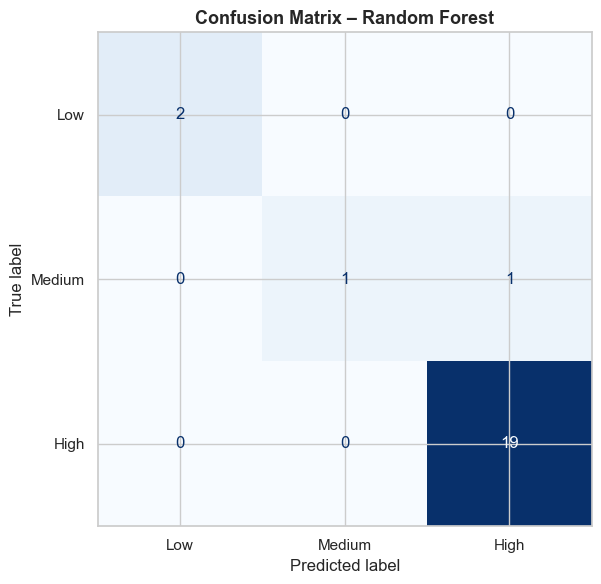

In [10]:
# Confusion Matrix
from sklearn.metrics import classification_report

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'Medium', 'High'])
print(cm)
print(classification_report(y_test, y_pred, target_names=['Low', 'Medium', 'High']))

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix – Random Forest', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

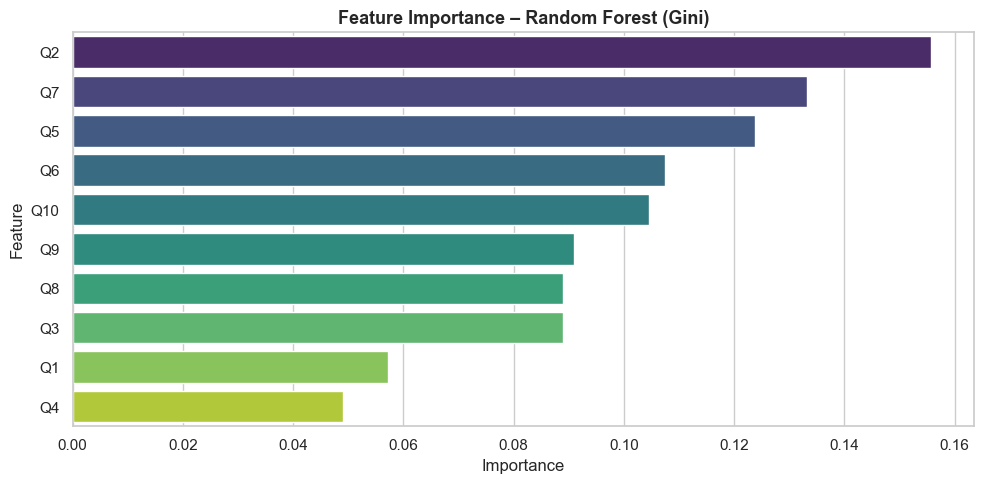

  feature  importance
0      Q2    0.155733
1      Q7    0.133305
2      Q5    0.123841
3      Q6    0.107497
4     Q10    0.104603
5      Q9    0.091001
6      Q8    0.089000
7      Q3    0.088871
8      Q1    0.057153
9      Q4    0.048996


In [11]:
# Native Feature Importance  (Gini impurity-based)
importances = rf_model.feature_importances_
feature_names = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Q6', 'Q7', 'Q8', 'Q9', 'Q10']

fi_df = pd.DataFrame({'feature': feature_names, 'importance': importances})
fi_df = fi_df.sort_values('importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 5))
sns.barplot(x='importance', y='feature', data=fi_df, palette='viridis')
plt.title('Feature Importance – Random Forest (Gini)', fontsize=13, fontweight='bold')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print(fi_df)

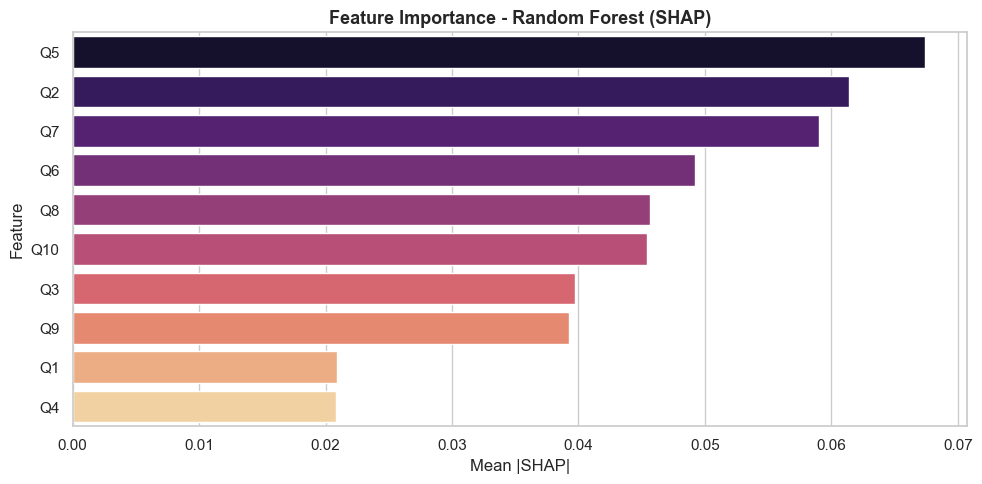

  feature  importance
0      Q5    0.067369
1      Q2    0.061427
2      Q7    0.059046
3      Q6    0.049223
4      Q8    0.045621
5     Q10    0.045414
6      Q3    0.039706
7      Q9    0.039250
8      Q1    0.020882
9      Q4    0.020853


In [12]:
# SHAP Explainability
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_train)

# Handle different SHAP output formats
if isinstance(shap_values, list):
    # Older SHAP versions
    mean_shap_per_feature = np.mean(
        [np.abs(sv).mean(axis=0) for sv in shap_values],
        axis=0
    )
else:
    # Newer SHAP versions: (samples, features, classes)
    mean_shap_per_feature = np.abs(shap_values).mean(axis=(0, 2))

# Create feature importance dataframe
shap_fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': mean_shap_per_feature
})

shap_fi_df = (
    shap_fi_df
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(
    data=shap_fi_df,
    x='importance',
    y='feature',
    palette='magma'
)

plt.title('Feature Importance - Random Forest (SHAP)',
          fontsize=13,
          fontweight='bold')
plt.xlabel('Mean |SHAP|')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print(shap_fi_df)

In [13]:
# Save all artifacts to backend/ml_models/random_forest/
SAVE_DIR = '../backend/ml_models/random_forest'
os.makedirs(SAVE_DIR, exist_ok=True)

# 1. Save the model
joblib.dump(rf_model, os.path.join(SAVE_DIR, 'random_forest_model.pkl'))
print("Saved: random_forest_model.pkl")

# 2. Save X_train (needed for SHAP background)
joblib.dump(X_train, os.path.join(SAVE_DIR, 'X_train.pkl'))
print("Saved: X_train.pkl")

# 3. Save SHAP TreeExplainer
joblib.dump(explainer, os.path.join(SAVE_DIR, 'shap_explainer.pkl'))
print("Saved: shap_explainer.pkl")

# 4. Save evaluation metrics
eval_metrics = [
    {
        "model_name": "Random Forest",
    # NOTE: accuracy/f1/auc_roc/cv_mean/cv_std must come from the
    # variables computed in Cell 6 & 7 above (rf_model). If the JSON
    # on disk matches XGBoost values exactly, this cell was never
    # re-run after the initial copy-paste. Restart & Run All to fix.
        "accuracy": round(accuracy, 4),
        "f1_score": round(f1, 4),
        "auc_roc": round(auc_roc, 4),
        "cv_mean": round(cv_mean, 4),
        "cv_std": round(cv_std, 4)
    }
]
with open(os.path.join(SAVE_DIR, 'evaluation_metrics.json'), 'w') as f:
    json.dump(eval_metrics, f, indent=4)
print("Saved: evaluation_metrics.json")

# 5. Save SHAP-based feature importance
feature_importance_list = shap_fi_df.to_dict(orient='records')
with open(os.path.join(SAVE_DIR, 'feature_importance.json'), 'w') as f:
    json.dump(feature_importance_list, f, indent=4)
print("Saved: feature_importance.json")

print(f"\nAll artifacts saved to: {SAVE_DIR}")
print(f"\nFinal Metrics:")
print(f"  Accuracy : {accuracy:.4f}")
print(f"  F1 Score : {f1:.4f}")
print(f"  AUC-ROC  : {auc_roc:.4f}")
print(f"  CV Mean  : {cv_mean:.4f} ± {cv_std:.4f}")

Saved: random_forest_model.pkl
Saved: X_train.pkl
Saved: shap_explainer.pkl
Saved: evaluation_metrics.json
Saved: feature_importance.json

All artifacts saved to: ../backend/ml_models/random_forest

Final Metrics:
  Accuracy : 0.9565
  F1 Score : 0.9498
  AUC-ROC  : 0.9612
  CV Mean  : 0.9213 ± 0.0321
